In [1]:
# ============================================================
# NOTEBOOK: 3_r_analytics.ipynb
# PURPOSE:
# Statistical Analysis and Visualisation in R
# ============================================================

# ============================================================
# STEP 1 — INSTALL R SUPPORT
# ============================================================

!pip install rpy2

# ============================================================
# STEP 2 — LOAD R EXTENSION
# ============================================================

%load_ext rpy2.ipython

In [2]:
%%R

print("R analytics environment working!")

[1] "R analytics environment working!"


In [3]:
# ============================================================
# STEP 3 — IMPORT PYTHON LIBRARIES
# ============================================================

import pandas as pd
import zipfile
import os

# ============================================================
# STEP 4 — EXTRACT DATASET
# ============================================================

zip_path = "/content/northstar_dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/data")

print("DATASET EXTRACTED SUCCESSFULLY!")

# ============================================================
# STEP 5 — LOAD DATASETS
# ============================================================

customers = pd.read_csv('/content/data/northstar_dataset/customers.csv')
orders = pd.read_csv('/content/data/northstar_dataset/orders.csv')
deliveries = pd.read_csv('/content/data/northstar_dataset/deliveries.csv')
drivers = pd.read_csv('/content/data/northstar_dataset/drivers.csv')
vehicles = pd.read_csv('/content/data/northstar_dataset/vehicles.csv')
complaints = pd.read_csv('/content/data/northstar_dataset/complaints.csv')
incidents = pd.read_csv('/content/data/northstar_dataset/incidents.csv')
hubs = pd.read_csv('/content/data/northstar_dataset/hubs.csv')
app_events = pd.read_csv('/content/data/northstar_dataset/app_events.csv')

print("ALL DATASETS LOADED!")

DATASET EXTRACTED SUCCESSFULLY!
ALL DATASETS LOADED!


In [4]:
# ============================================================
# STEP 6 — SEND DATAFRAMES TO R
# ============================================================

%R -i customers
%R -i orders
%R -i deliveries
%R -i drivers
%R -i vehicles
%R -i complaints
%R -i incidents
%R -i hubs
%R -i app_events

print("DATA SENT TO R SUCCESSFULLY!")

DATA SENT TO R SUCCESSFULLY!


/usr/local/lib/python3.12/dist-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "order_id". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


In [5]:
%%R

# ============================================================
# STEP 7 — INSTALL REQUIRED PACKAGES
# ============================================================

install.packages("ggplot2")
install.packages("dplyr")
install.packages("corrplot")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggplot2_4.0.3.tar.gz'
Content type 'application/x-gzip' length 6327703 bytes (6.0 MB)
downloaded 6.0 MB


The downloaded source packages are in
	‘/tmp/RtmpqFsIAj/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/dplyr_1.2.1.tar.gz'
Content type 'application/x-gzip' length 923509 bytes (901 KB)
downloaded 901 KB


The downloaded source packages are in
	‘/tmp/RtmpqFsIAj/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/corrplot_0.95.tar.gz'
Content type 'application/x-gzip' length 3745190 bytes (3.6 MB)
downloaded 3.6 MB


The downloaded source packages are in
	‘/tmp/RtmpqFsIAj/downloaded_packages’


In [6]:
%%R

# ============================================================
# STEP 8 — LOAD LIBRARIES
# ============================================================

library(ggplot2)
library(dplyr)
library(corrplot)

cat("R ANALYTICS LIBRARIES LOADED!\n")

R ANALYTICS LIBRARIES LOADED!



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

corrplot 0.95 loaded


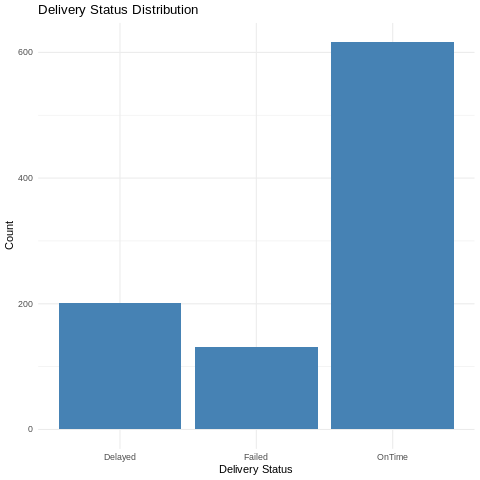

In [7]:
%%R

# ============================================================
# CHART 1 — DELIVERY STATUS DISTRIBUTION
# ============================================================

ggplot(deliveries, aes(x = delivery_status)) +
  geom_bar(fill = "steelblue") +
  labs(
    title = "Delivery Status Distribution",
    x = "Delivery Status",
    y = "Count"
  ) +
  theme_minimal()

INTERPRETATION:

This visualisation shows the overall distribution of delivery outcomes.
The presence of delayed and failed deliveries indicates operational inefficiencies
that may negatively influence customer satisfaction and service reliability.

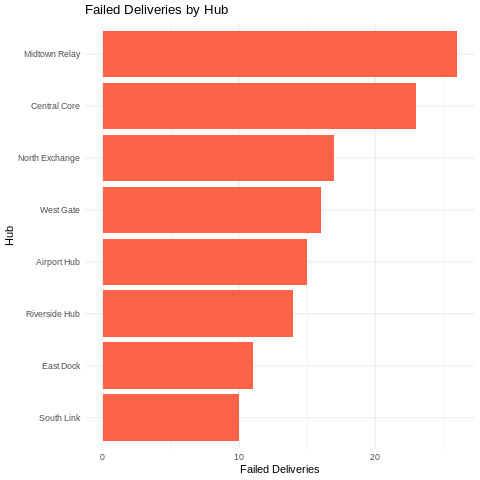

In [8]:
%%R

# ============================================================
# CHART 2 — FAILED DELIVERIES BY HUB
# ============================================================

failed_hub <- deliveries %>%
  filter(delivery_status == "Failed") %>%
  group_by(hub_id) %>%
  summarise(total_failed = n())

hub_join <- merge(failed_hub, hubs, by = "hub_id")

ggplot(hub_join,
       aes(x = reorder(hub_name, total_failed),
           y = total_failed)) +
  geom_bar(stat = "identity", fill = "tomato") +
  coord_flip() +
  labs(
    title = "Failed Deliveries by Hub",
    x = "Hub",
    y = "Failed Deliveries"
  ) +
  theme_minimal()

INTERPRETATION:

This chart identifies operational hubs with the highest failure rates.
Midtown Relay and Central Core demonstrate significantly higher failed deliveries,
suggesting dispatch inefficiencies, route instability, or operational overload.

`geom_smooth()` using formula = 'y ~ x'




(`geom_point()`). 



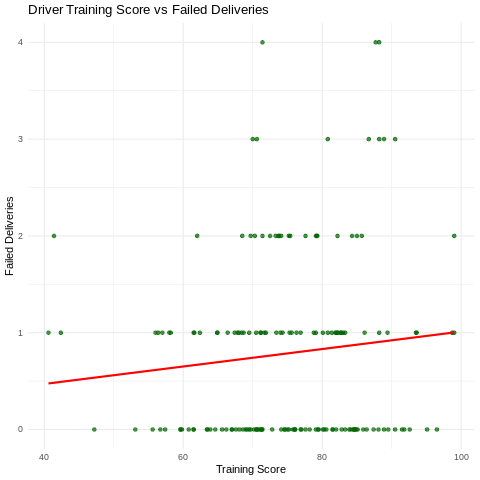

In [9]:
%%R

# ============================================================
# CHART 3 — DRIVER TRAINING VS FAILED DELIVERIES
# ============================================================

driver_analysis <- deliveries %>%
  group_by(driver_id) %>%
  summarise(
    failed_deliveries =
      sum(delivery_status == "Failed")
  )

driver_join <- merge(driver_analysis,
                     drivers,
                     by = "driver_id")

ggplot(driver_join,
       aes(x = training_score,
           y = failed_deliveries)) +
  geom_point(color = "darkgreen", alpha = 0.7) +
  geom_smooth(method = "lm", se = FALSE, color = "red") +
  labs(
    title = "Driver Training Score vs Failed Deliveries",
    x = "Training Score",
    y = "Failed Deliveries"
  ) +
  theme_minimal()

INTERPRETATION:

This analysis investigates whether lower driver training scores
are associated with higher delivery failure rates.

The trendline helps evaluate workforce capability and training effectiveness.

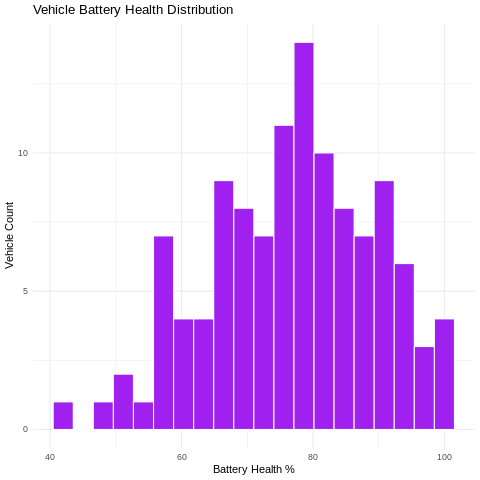

In [10]:
%%R

# ============================================================
# CHART 4 — VEHICLE BATTERY HEALTH DISTRIBUTION
# ============================================================

ggplot(vehicles,
       aes(x = battery_health_pct)) +
  geom_histogram(
    bins = 20,
    fill = "purple",
    color = "white"
  ) +
  labs(
    title = "Vehicle Battery Health Distribution",
    x = "Battery Health %",
    y = "Vehicle Count"
  ) +
  theme_minimal()

INTERPRETATION:

Battery health distribution helps identify fleet condition trends.
Lower battery health levels may contribute to service interruptions,
operational delays, and increased maintenance incidents.

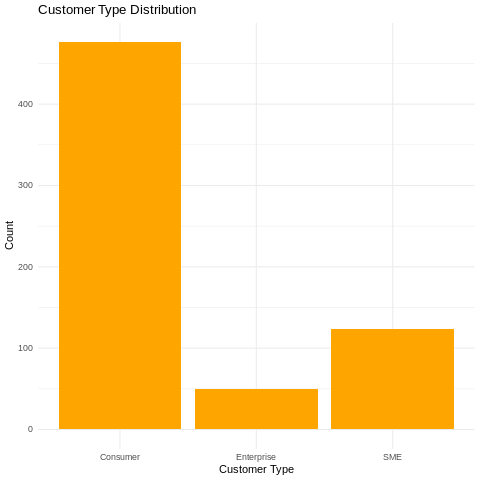

In [11]:
%%R

# ============================================================
# CHART 5 — CUSTOMER TYPE DISTRIBUTION
# ============================================================

ggplot(customers,
       aes(x = customer_type)) +
  geom_bar(fill = "orange") +
  labs(
    title = "Customer Type Distribution",
    x = "Customer Type",
    y = "Count"
  ) +
  theme_minimal()

INTERPRETATION:

This chart shows the composition of customer segments,
including Consumer, SME, and Enterprise clients.

The findings help evaluate which customer groups may face
higher operational risk exposure.

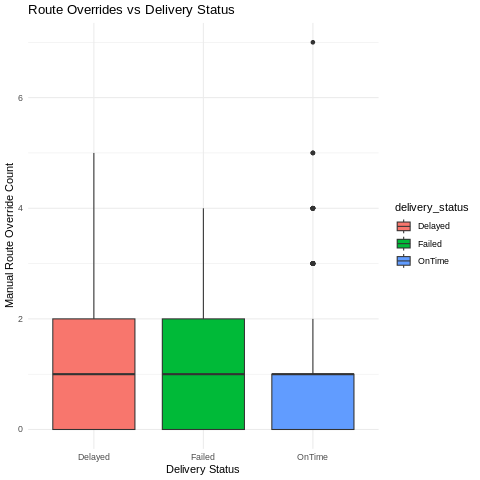

In [12]:
%%R

# ============================================================
# CHART 6 — ROUTE OVERRIDES VS DELIVERY STATUS
# ============================================================

ggplot(deliveries,
       aes(x = delivery_status,
           y = manual_route_override_count,
           fill = delivery_status)) +
  geom_boxplot() +
  labs(
    title = "Route Overrides vs Delivery Status",
    x = "Delivery Status",
    y = "Manual Route Override Count"
  ) +
  theme_minimal()

INTERPRETATION:

This visualisation evaluates whether higher route override activity
is associated with failed or delayed deliveries.

The findings support the case study concern regarding
manual dispatch interventions and route instability.

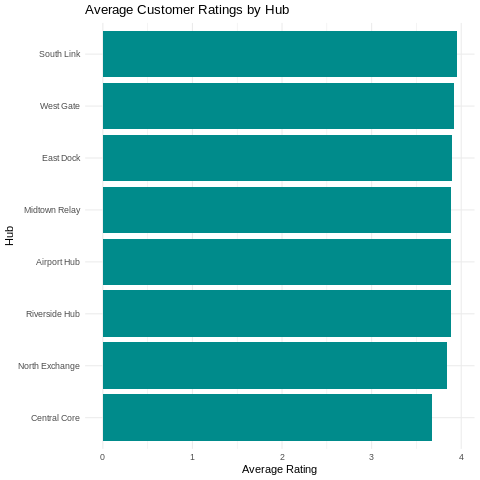

In [13]:
%%R

# ============================================================
# CHART 7 — CUSTOMER RATINGS BY HUB
# ============================================================

hub_ratings <- deliveries %>%
  group_by(hub_id) %>%
  summarise(
    avg_rating =
      mean(customer_rating_post_delivery,
           na.rm = TRUE)
  )

hub_rating_join <- merge(hub_ratings,
                         hubs,
                         by = "hub_id")

ggplot(hub_rating_join,
       aes(x = reorder(hub_name, avg_rating),
           y = avg_rating)) +
  geom_bar(stat = "identity",
           fill = "darkcyan") +
  coord_flip() +
  labs(
    title = "Average Customer Ratings by Hub",
    x = "Hub",
    y = "Average Rating"
  ) +
  theme_minimal()

INTERPRETATION:

This analysis compares customer satisfaction levels across hubs.
Lower-rated hubs may indicate operational inconsistency,
delivery quality problems, or customer service weaknesses.

In [14]:
%%R

# ============================================================
# STATISTICAL ANALYSIS — CORRELATION
# ============================================================

correlation_data <- deliveries %>%
  select(
    route_distance_km,
    manual_route_override_count,
    customer_rating_post_delivery
  )

cor_matrix <- cor(correlation_data,
                  use = "complete.obs")

print(cor_matrix)

                              route_distance_km manual_route_override_count
route_distance_km                    1.00000000                  0.19938470
manual_route_override_count          0.19938470                  1.00000000
customer_rating_post_delivery        0.02852525                 -0.05990295
                              customer_rating_post_delivery
route_distance_km                                0.02852525
manual_route_override_count                     -0.05990295
customer_rating_post_delivery                    1.00000000


INTERPRETATION:

Correlation analysis evaluates relationships between:
- route distance
- manual route overrides
- customer satisfaction

Strong relationships may indicate operational inefficiencies
that negatively influence delivery quality.

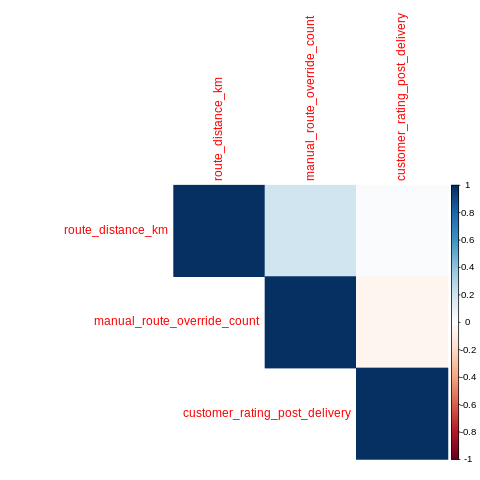

In [15]:
%%R

# ============================================================
# CORRELATION HEATMAP
# ============================================================

corrplot(cor_matrix,
         method = "color",
         type = "upper")

In [16]:
%%R

# ============================================================
# REGRESSION ANALYSIS
# ============================================================

regression_model <- lm(
  customer_rating_post_delivery ~
  route_distance_km +
  manual_route_override_count,
  data = deliveries
)

summary(regression_model)


Call:
lm(formula = customer_rating_post_delivery ~ route_distance_km + 
    manual_route_override_count, data = deliveries)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.9540 -0.4887  0.1734  0.6731  1.2900 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  3.848653   0.063632  60.483   <2e-16 ***
route_distance_km            0.005067   0.004006   1.265   0.2063    
manual_route_override_count -0.055815   0.027228  -2.050   0.0406 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.893 on 933 degrees of freedom
  (14 observations deleted due to missingness)
Multiple R-squared:  0.005294,	Adjusted R-squared:  0.003162 
F-statistic: 2.483 on 2 and 933 DF,  p-value: 0.08406



INTERPRETATION:

Regression analysis evaluates whether route complexity
and manual route overrides influence customer satisfaction.

This supports deeper investigation into operational inefficiency
and delivery quality performance.

In [17]:
%%R

cat("=====================================================\n")
cat("R ANALYTICS COMPLETE\n")
cat("=====================================================\n")

cat("Completed Analytics:\n")
cat("1. Delivery status distribution\n")
cat("2. Failed deliveries by hub\n")
cat("3. Driver training analysis\n")
cat("4. Battery health analysis\n")
cat("5. Customer segmentation\n")
cat("6. Route override analysis\n")
cat("7. Customer ratings by hub\n")
cat("8. Correlation analysis\n")
cat("9. Regression analysis\n")

cat("\nNEXT NOTEBOOK:\n")
cat("4_python_processing.ipynb\n")

R ANALYTICS COMPLETE
Completed Analytics:
1. Delivery status distribution
2. Failed deliveries by hub
3. Driver training analysis
4. Battery health analysis
5. Customer segmentation
6. Route override analysis
7. Customer ratings by hub
8. Correlation analysis
9. Regression analysis

NEXT NOTEBOOK:
4_python_processing.ipynb
